Author: Raphael Balzer  
GitHub Copilot was used to assist with code

# Isolation Forest

In [ ]:
import sys
sys.path.insert(0, '..')

## Data Preparation

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, message=".*CategoricalDtype.*")
# Configuration
CONFIG = {
    'dataset_path': 'data/train_test_network.csv',
    'enable_monitoring': True,
    'random_state': 42
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print("\n  Important: random_state must match training notebook to ensure same test set!")

Configuration:
  dataset_path: data/train_test_network.csv
  enable_monitoring: True
  random_state: 42

  Important: random_state must match training notebook to ensure same test set!


In [2]:
from ton_iot_pipeline import load_and_split_data

X_train, X_val, X_test, y_train, y_val, y_test, _, _, _ = load_and_split_data(
    filepath=CONFIG['dataset_path'],
    random_state=CONFIG['random_state']
)

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...
Dataset shape: (211043, 44)
Features: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Data split (stratified by attack type):
  Train: 147,730 samples (70.0%)
  Val:   31,656 samples (15.0%)
  Test:  31,657 samples (15.0%)

Label distribution (0=normal, 1=attack):
  Train: 76.31% attacks
  Val:   76.31% attacks
  Test:  76.31% attacks


In [3]:
from preprocessing import FancyIFPreprocessor

preprocessor = FancyIFPreprocessor()
X_train = preprocessor.fit_transform(X_train)
# taking only normal data for training
#X_train = X_train[y_train == 0]
X_val = preprocessor.transform(X_val)

## Tuning Isolation Forest with Optuna

In [4]:
from preprocessing_copy import IsoTreeTuner, PredictorWrapper

tuner = IsoTreeTuner(X_train, y_train)
best_params = tuner.tune(n_trials=10)
print("Best hyperparameters found:")
for params in best_params:
    print(f" Architecture: {params['architecture']}")
    for key, value in params['params'].items():
        print(f"    {key}: {value}")

Starte Benchmark für 4 Varianten mit je 10 Trials...

--- Processing: IF ---

--- Processing: EIF ---

--- Processing: SCIF ---

--- Processing: FCF ---
Best hyperparameters found:
 Architecture: IF
    ntrees: 100
    missing_action: fail
    scoring_metric: depth
    random_state: 42
    sample_size: 2048
    ndim: 1
    ntry: 1
    coefs: uniform
    prob_pick_avg_gain: 0.0
    prob_pick_pooled_gain: 0.0
    penalize_range: False
    max_depth: 15
 Architecture: EIF
    ntrees: 100
    missing_action: fail
    scoring_metric: depth
    random_state: 42
    sample_size: 2048
    ndim: 2
    ntry: 1
    coefs: uniform
    prob_pick_avg_gain: 0.0
    prob_pick_pooled_gain: 0.0
    penalize_range: False
    max_depth: 15
 Architecture: SCIF
    ntrees: 100
    missing_action: fail
    scoring_metric: depth
    random_state: 42
    sample_size: 256
    ndim: 2
    ntry: 6
    coefs: normal
    prob_pick_avg_gain: 0.7733551396716398
    prob_pick_pooled_gain: 0.0
    penalize_range: True


## Evaluating the best models


=== Evaluating model: IF ===

Baue Modell für 'IF' mit besten Parametern...
Parameter: {'ntrees': 100, 'missing_action': 'fail', 'scoring_metric': 'depth', 'random_state': 42, 'sample_size': 2048, 'ndim': 1, 'ntry': 1, 'coefs': 'uniform', 'prob_pick_avg_gain': 0.0, 'prob_pick_pooled_gain': 0.0, 'penalize_range': False, 'max_depth': 15}
Modell erfolgreich trainiert.
Optimaler Threshold gefunden: 0.2972 (Max F2: 0.9368)
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      7500
      Attack       0.76      0.99      0.86     24156

    accuracy                           0.76     31656
   macro avg       0.38      0.50      0.43     31656
weighted avg       0.58      0.76      0.66     31656



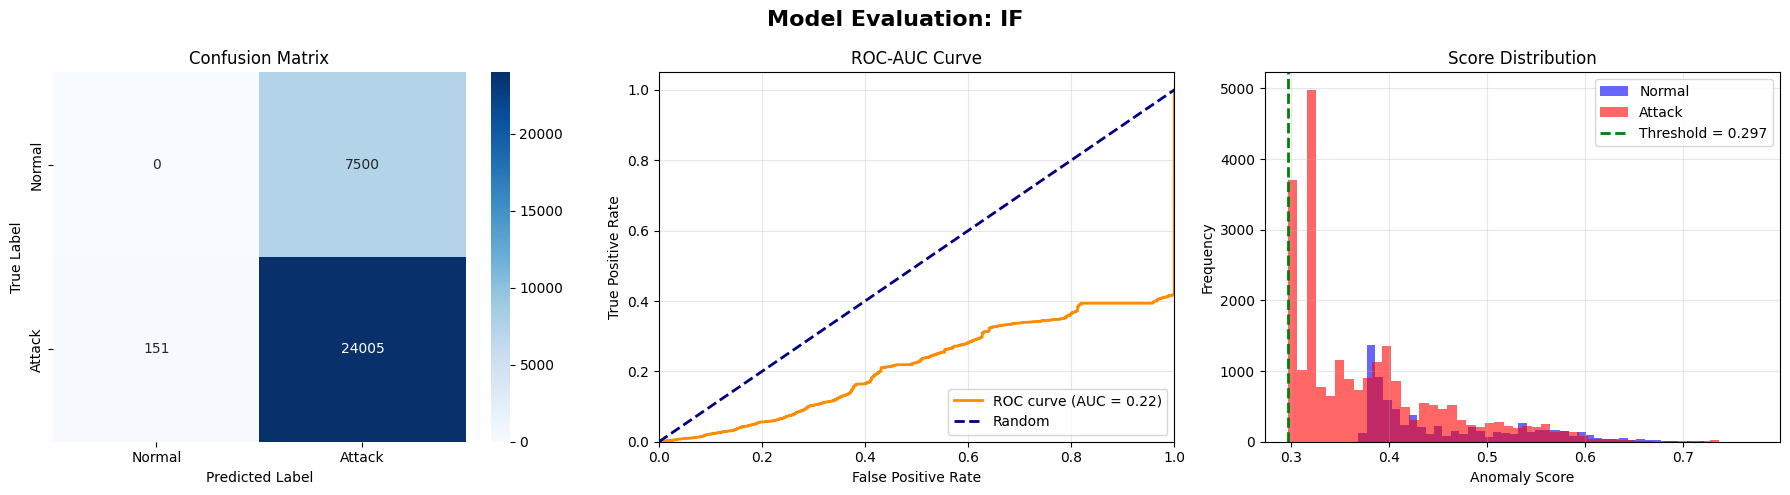

Saved model to models/IF_feat_eng.pkl

=== Evaluating model: EIF ===

Baue Modell für 'EIF' mit besten Parametern...
Parameter: {'ntrees': 100, 'missing_action': 'fail', 'scoring_metric': 'depth', 'random_state': 42, 'sample_size': 2048, 'ndim': 2, 'ntry': 1, 'coefs': 'uniform', 'prob_pick_avg_gain': 0.0, 'prob_pick_pooled_gain': 0.0, 'penalize_range': False, 'max_depth': 15}
Modell erfolgreich trainiert.
Optimaler Threshold gefunden: 0.2840 (Max F2: 0.9122)
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      7500
      Attack       0.76      0.96      0.85     24156

    accuracy                           0.73     31656
   macro avg       0.38      0.48      0.42     31656
weighted avg       0.58      0.73      0.65     31656



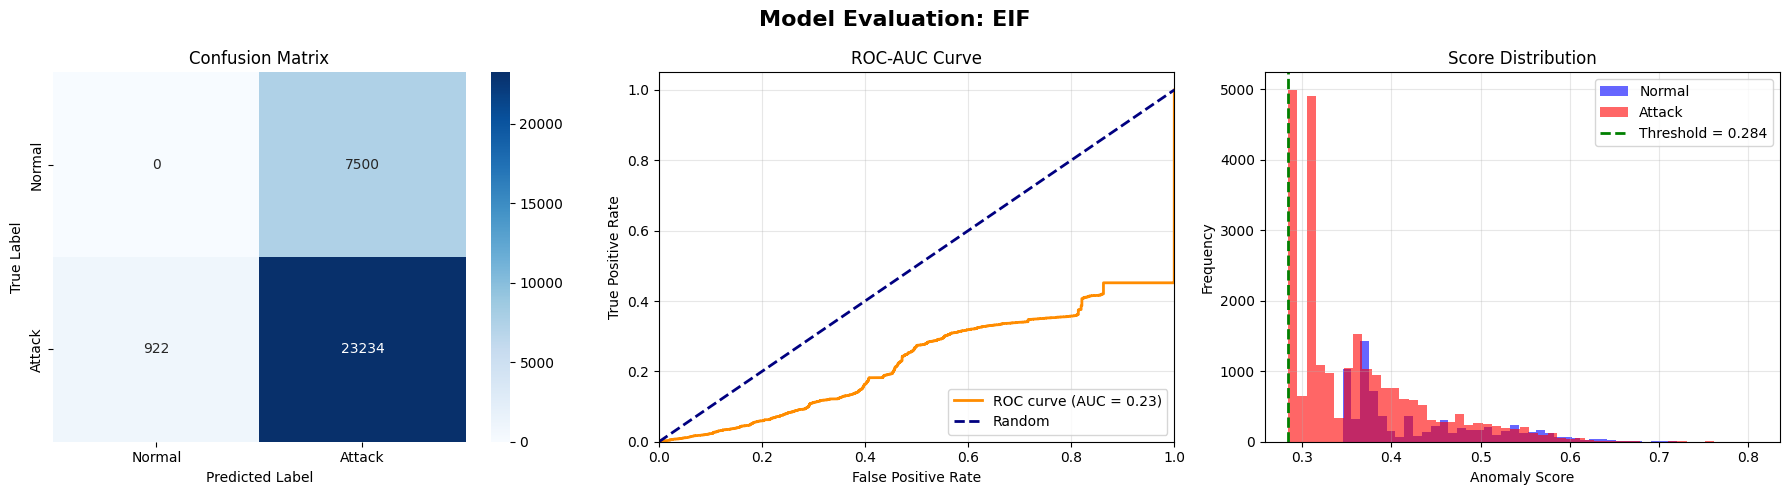

Saved model to models/EIF_feat_eng.pkl

=== Evaluating model: SCIF ===

Baue Modell für 'SCIF' mit besten Parametern...
Parameter: {'ntrees': 100, 'missing_action': 'fail', 'scoring_metric': 'depth', 'random_state': 42, 'sample_size': 256, 'ndim': 2, 'ntry': 6, 'coefs': 'normal', 'prob_pick_avg_gain': 0.7733551396716398, 'prob_pick_pooled_gain': 0.0, 'penalize_range': True, 'max_depth': 7}
Modell erfolgreich trainiert.
Optimaler Threshold gefunden: 0.3670 (Max F2: 0.8594)
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      7500
      Attack       0.74      0.89      0.81     24156

    accuracy                           0.68     31656
   macro avg       0.37      0.45      0.41     31656
weighted avg       0.57      0.68      0.62     31656



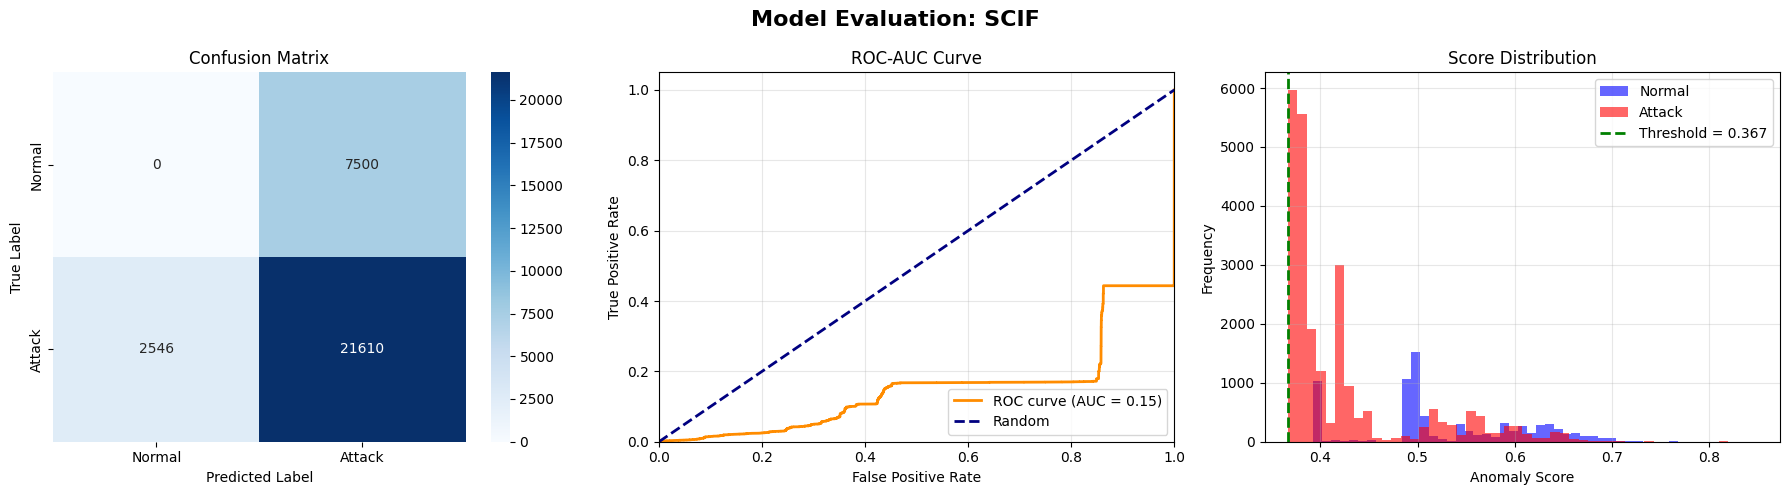

Saved model to models/SCIF_feat_eng.pkl

=== Evaluating model: FCF ===

Baue Modell für 'FCF' mit besten Parametern...
Parameter: {'ntrees': 100, 'missing_action': 'fail', 'scoring_metric': 'depth', 'random_state': 42, 'sample_size': 1024, 'ndim': 2, 'ntry': 5, 'coefs': 'normal', 'prob_pick_avg_gain': 0.0, 'prob_pick_pooled_gain': 0.728034992108518, 'penalize_range': True, 'max_depth': 7}
Modell erfolgreich trainiert.
Optimaler Threshold gefunden: 0.3943 (Max F2: 0.7986)
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      7500
      Attack       0.73      0.82      0.77     24156

    accuracy                           0.63     31656
   macro avg       0.36      0.41      0.38     31656
weighted avg       0.55      0.63      0.59     31656



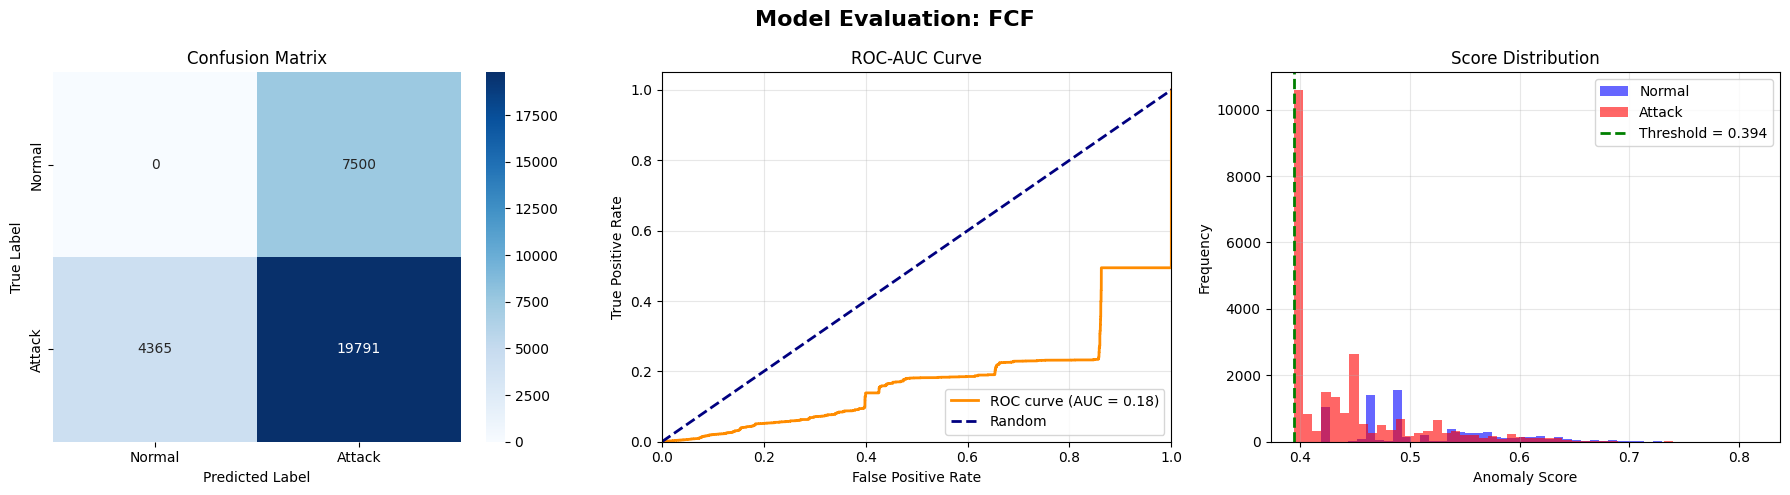

Saved model to models/FCF_feat_eng.pkl


In [5]:
import pickle

model_names = ["IF", "EIF", "SCIF", "FCF"]
models = {}
for model_name in model_names:
    print(f"\n=== Evaluating model: {model_name} ===")
    model = tuner.build_model(model_name)
    models[model_name] = model
    predictor = PredictorWrapper(model, model_name, X_val, y_val)
    predictor.predict()
    predictor.evaluate()
    checkpoint = {
        "model": model,
        "threshold": predictor.best_threshold,
        "preprocessor": preprocessor
    }
    with open(f"models/{model_name}_feat_eng.pkl", "wb") as f:
        pickle.dump(checkpoint, f)
        print(f"Saved model to models/{model_name}_feat_eng.pkl")

## Feature Importance

Berechne Importances für 4 Modelle (Top 15 Features)...


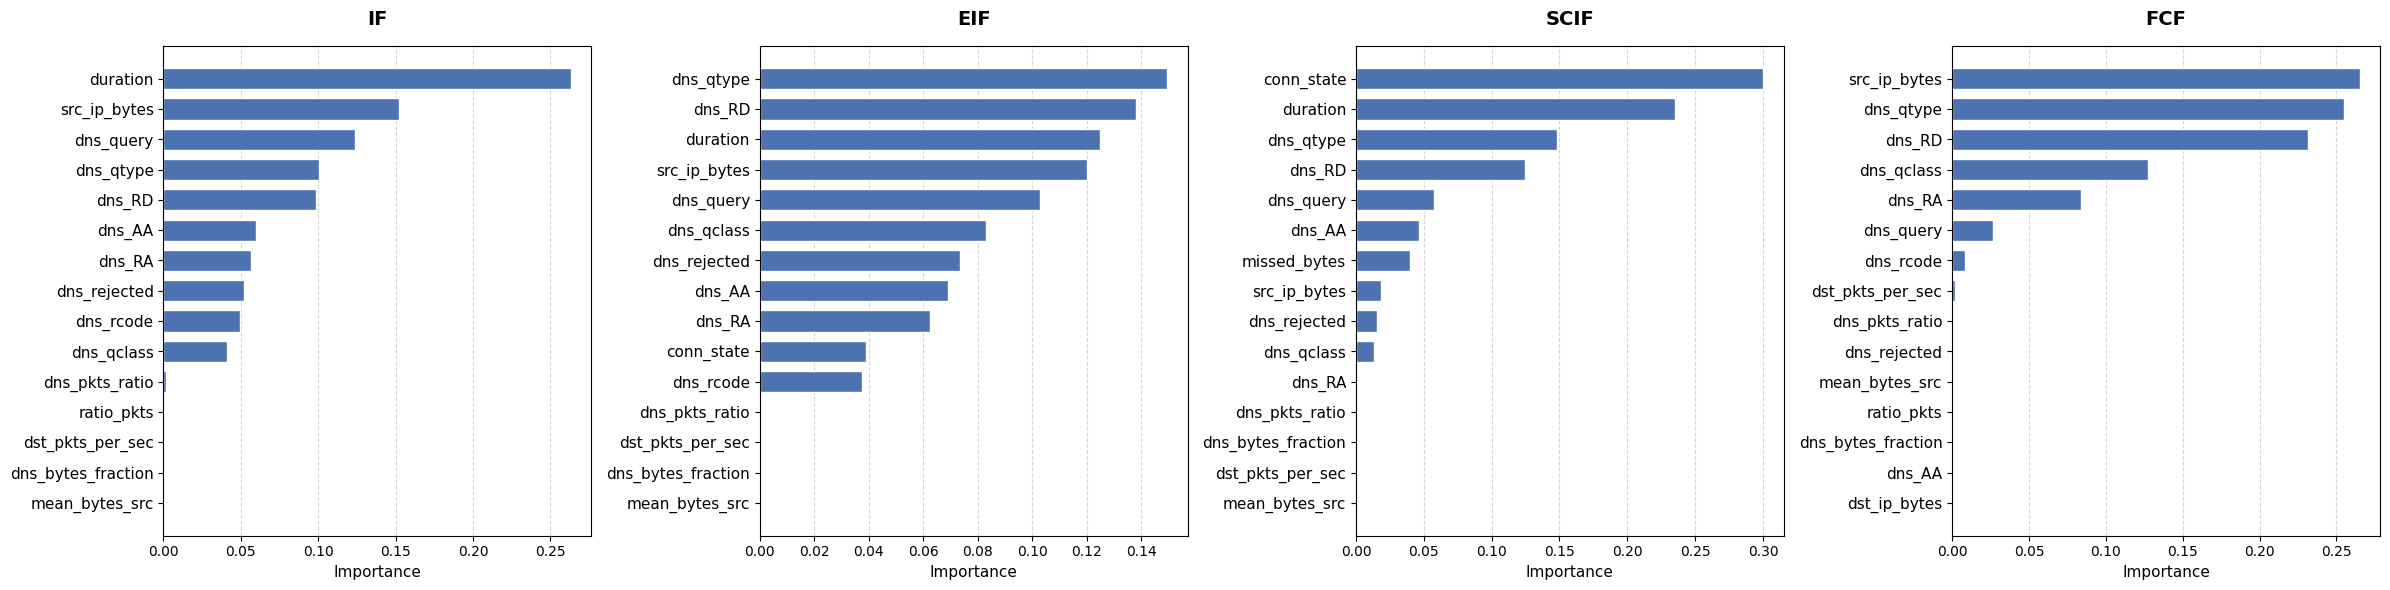

In [6]:
from ton_iot_utils import plot_feature_importances

# Feature-Importances für alle Modelle visualisieren (mit Klassenlabels für bessere Metrik)
importances = plot_feature_importances(models, X_val, y_val)

In [7]:
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# import numpy as np
# # tsne only for numerical features

# X_val_numeric = X_val.select_dtypes(include=[np.number])

# tsne = TSNE(n_components=2, random_state=42)
# X_val_2d = tsne.fit_transform(X_val_numeric)
# plt.figure(figsize=(10, 6))
# plt.scatter(
#     X_val_2d[y_val == 0, 0], X_val_2d[y_val == 0, 1],
#     c='#1f77b4', label='Normal', alpha=0.5
# )
# plt.scatter(
#     X_val_2d[y_val == 1, 0], X_val_2d[y_val == 1, 1],
#     c='#d62728', label='Angriff', alpha=0.5
# )
# plt.legend()
# plt.title('t-SNE Projektion von X_val')
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
# plt.show()